In [1]:
from load_data import load_raw_data
from clean_data import clean_data
from split_data import split_data
from build_pipeline import build_pipeline
from evaluate_model import evaluate_model, view_ROC_curve,view_PR_curve
from feature_engineering import build_new_features
from config import RANDOM_STATE
import logging

In [2]:
logging.basicConfig(
    level=logging.INFO,format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

In [3]:
# Loading raw data
dataset=load_raw_data()

2026-09-08 11:09:05,684 | INFO | load_data | Raw dataset loaded.


In [4]:
# Cleaning data
dataset_cleaned=clean_data(dataset, save=False)

2026-09-08 11:09:05,689 | INFO | clean_data | Dropped customerID.
2026-09-08 11:09:05,691 | INFO | clean_data | Converted TotalCharges to numeric.
2026-09-08 11:09:05,694 | INFO | clean_data | Rows containing NaN before cleaning: 11
2026-09-08 11:09:05,699 | INFO | clean_data | Removed 11 rows with invalid TotalCharges. Remaining rows with NaN: 0.


In [5]:
# Adding new features
#dataset_cleaned=build_new_features(dataset_cleaned, new_features=["NumberServices","CustomerLevel","MonthlyChargePerService","AverageMonthlyCharge"])

In [6]:
# Splitting data
X_train, X_test, y_train, y_test=split_data(dataset_cleaned, random_state=RANDOM_STATE)

2026-09-08 11:09:05,709 | INFO | split_data | Data split into train/test set with 0.8/0.2 proportion and random_state=0.


### XGBoost

In [7]:
# Building XGBoost model
pipe_XGB=build_pipeline(trial=None,model='XGBoost')
fitted_pipe_XGB=pipe_XGB.fit(X_train, y_train)

### Logistic Regression

In [8]:
# Building Logistic Regression model
pipe_LR=build_pipeline(trial=None,model='Logistic Regression')
fitted_pipe_LR=pipe_LR.fit(X_train, y_train)

### K-Nearest Neighbors

In [9]:
# Building K-Nearest Neighbors
pipe_KNN=build_pipeline(trial=None,model='K-Nearest Neighbors')
fitted_pipe_KNN=pipe_KNN.fit(X_train, y_train)

### Support Vector Machine

In [10]:
# Building Support Vector Machine model
pipe_SVM=build_pipeline(trial=None,model='Support Vector Machine')
fitted_pipe_SVM=pipe_SVM.fit(X_train, y_train)

### Decision Tree

In [11]:
# Building Decision Tree model
pipe_DT=build_pipeline(trial=None,model='Decision Tree')
fitted_pipe_DT=pipe_DT.fit(X_train, y_train)

### Random Forest

In [12]:
# Building Random Forest model
pipe_RF=build_pipeline(trial=None,model='Random Forest')
fitted_pipe_RF=pipe_RF.fit(X_train, y_train)

### Model performances

In [13]:
metrics_XGB,report_XGB=evaluate_model(fitted_pipe_XGB,X_test,y_test,threshold=0.5)
metrics_XGB

2026-09-08 11:09:10,667 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for XGBClassifier classification model (Threshold: 0.5).


{'classifier_name': 'XGBClassifier',
 'threshold': 0.5,
 'accuracy': 0.786,
 'f1': 0.55,
 'f2': 0.514,
 'precision': 0.624,
 'recall': 0.492,
 'roc_auc': 0.824,
 'average_precision': 0.62,
 'confusion_matrix': [[922, 111], [190, 184]]}

In [14]:
metrics_LR,report_LR=evaluate_model(fitted_pipe_LR,X_test,y_test,threshold=0.5)
metrics_LR

2026-09-08 11:09:10,693 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for LogisticRegression classification model (Threshold: 0.5).


{'classifier_name': 'LogisticRegression',
 'threshold': 0.5,
 'accuracy': 0.753,
 'f1': 0.631,
 'f2': 0.72,
 'precision': 0.524,
 'recall': 0.794,
 'roc_auc': 0.851,
 'average_precision': 0.658,
 'confusion_matrix': [[763, 270], [77, 297]]}

In [15]:
metrics_KNN,report_KNN=evaluate_model(fitted_pipe_KNN,X_test,y_test,threshold=0.5)
metrics_KNN

2026-09-08 11:09:10,757 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for KNeighborsClassifier classification model (Threshold: 0.5).


{'classifier_name': 'KNeighborsClassifier',
 'threshold': 0.5,
 'accuracy': 0.765,
 'f1': 0.539,
 'f2': 0.525,
 'precision': 0.564,
 'recall': 0.516,
 'roc_auc': 0.788,
 'average_precision': 0.515,
 'confusion_matrix': [[884, 149], [181, 193]]}

In [16]:
metrics_SVM,report_SVM=evaluate_model(fitted_pipe_SVM,X_test,y_test,threshold=0.5)
metrics_SVM

2026-09-08 11:09:10,942 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for SVC classification model (Threshold: 0.5).


{'classifier_name': 'SVC',
 'threshold': 0.5,
 'accuracy': 0.797,
 'f1': 0.628,
 'f2': 0.638,
 'precision': 0.613,
 'recall': 0.644,
 'roc_auc': 0.83,
 'average_precision': 0.638,
 'confusion_matrix': [[881, 152], [133, 241]]}

In [17]:
metrics_DT,report_DT=evaluate_model(fitted_pipe_DT,X_test,y_test,threshold=0.5)
metrics_DT

2026-09-08 11:09:10,976 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for DecisionTreeClassifier classification model (Threshold: 0.5).


{'classifier_name': 'DecisionTreeClassifier',
 'threshold': 0.5,
 'accuracy': 0.746,
 'f1': 0.519,
 'f2': 0.517,
 'precision': 0.522,
 'recall': 0.516,
 'roc_auc': 0.672,
 'average_precision': 0.397,
 'confusion_matrix': [[856, 177], [181, 193]]}

In [18]:
metrics_RF,report_RF=evaluate_model(fitted_pipe_RF,X_test,y_test,threshold=0.5)
metrics_RF

2026-09-08 11:09:11,039 | INFO | evaluate_model | Calculated accuracy, f_1, f_2, precision, recall, roc_auc, average_precision, confusion_matrix and report for RandomForestClassifier classification model (Threshold: 0.5).


{'classifier_name': 'RandomForestClassifier',
 'threshold': 0.5,
 'accuracy': 0.786,
 'f1': 0.538,
 'f2': 0.494,
 'precision': 0.632,
 'recall': 0.468,
 'roc_auc': 0.825,
 'average_precision': 0.609,
 'confusion_matrix': [[931, 102], [199, 175]]}

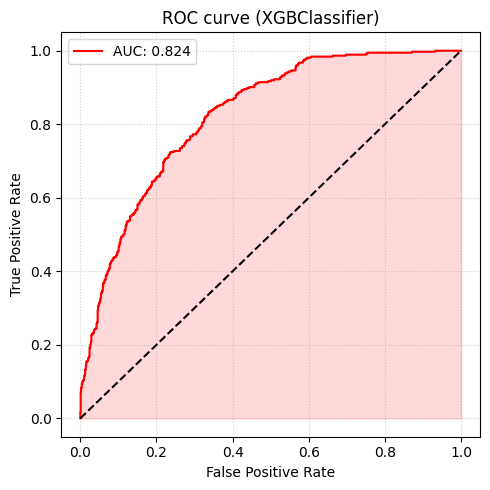

2026-09-08 11:09:11,174 | INFO | evaluate_model | ROC Curve and AUC for XGBClassifier classification model.


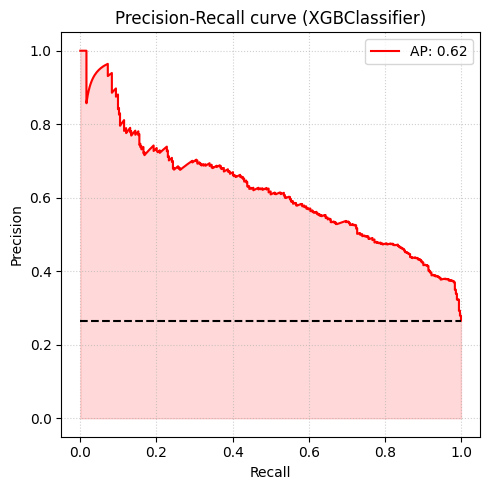

2026-09-08 11:09:11,265 | INFO | evaluate_model | Precision-Recall Curve for XGBClassifier classification model.


In [19]:
_,_=view_ROC_curve(fitted_pipe_XGB,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_XGB,X_test,y_test)

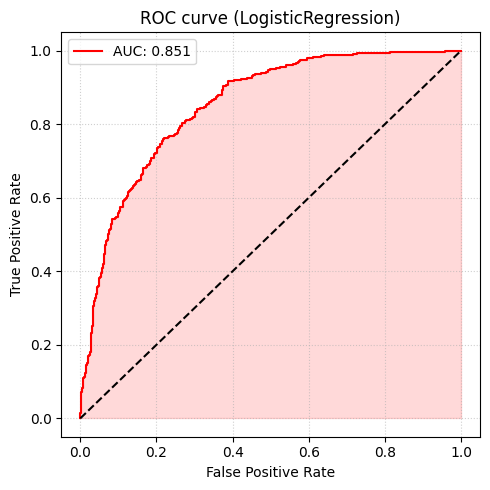

2026-09-08 11:09:11,377 | INFO | evaluate_model | ROC Curve and AUC for LogisticRegression classification model.


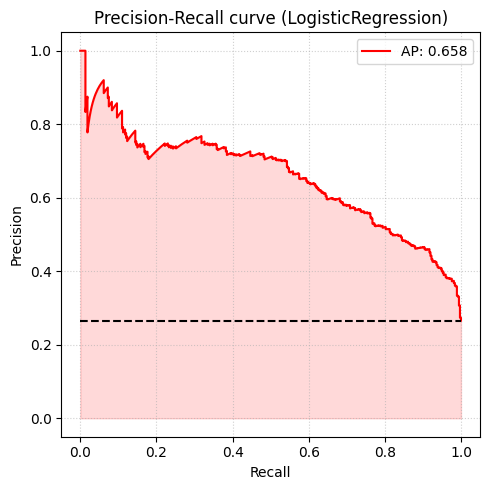

2026-09-08 11:09:11,472 | INFO | evaluate_model | Precision-Recall Curve for LogisticRegression classification model.


In [20]:
_,_=view_ROC_curve(fitted_pipe_LR,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_LR,X_test,y_test)

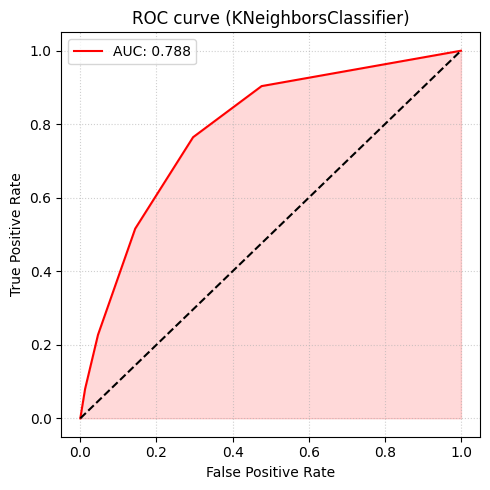

2026-09-08 11:09:11,590 | INFO | evaluate_model | ROC Curve and AUC for KNeighborsClassifier classification model.


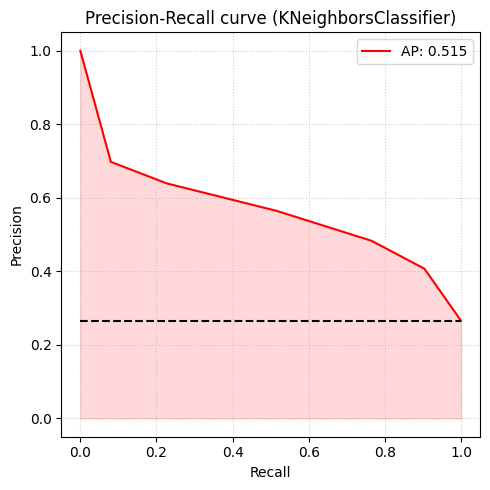

2026-09-08 11:09:11,690 | INFO | evaluate_model | Precision-Recall Curve for KNeighborsClassifier classification model.


In [21]:
_,_=view_ROC_curve(fitted_pipe_KNN,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_KNN,X_test,y_test)

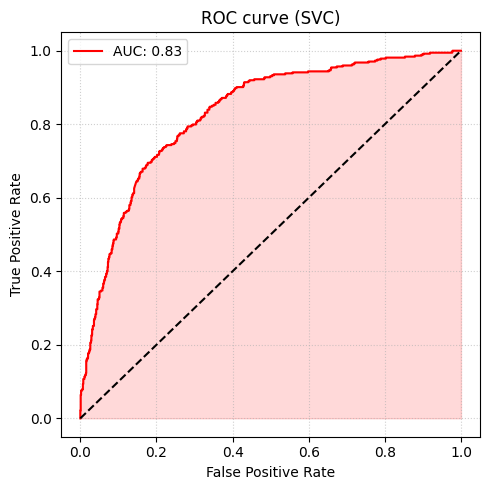

2026-09-08 11:09:11,958 | INFO | evaluate_model | ROC Curve and AUC for SVC classification model.


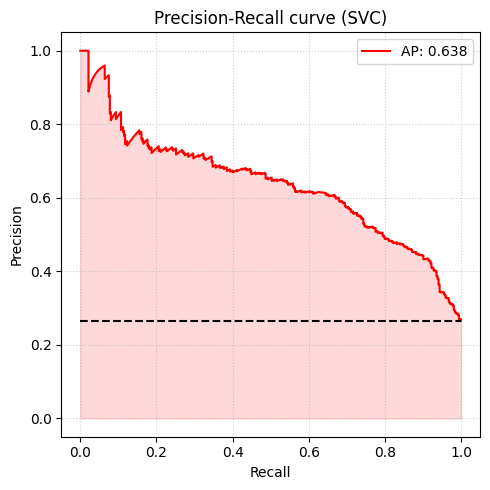

2026-09-08 11:09:12,213 | INFO | evaluate_model | Precision-Recall Curve for SVC classification model.


In [22]:
_,_=view_ROC_curve(fitted_pipe_SVM,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_SVM,X_test,y_test)

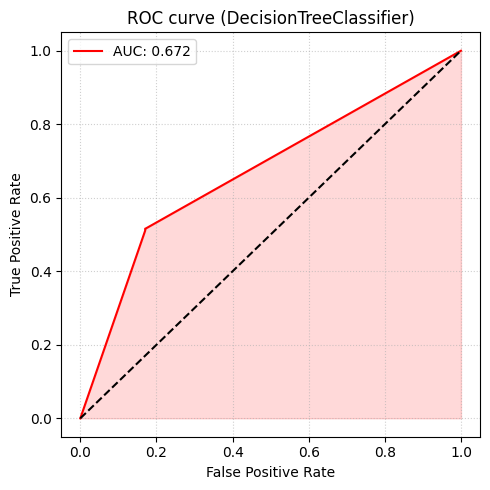

2026-09-08 11:09:12,407 | INFO | evaluate_model | ROC Curve and AUC for DecisionTreeClassifier classification model.


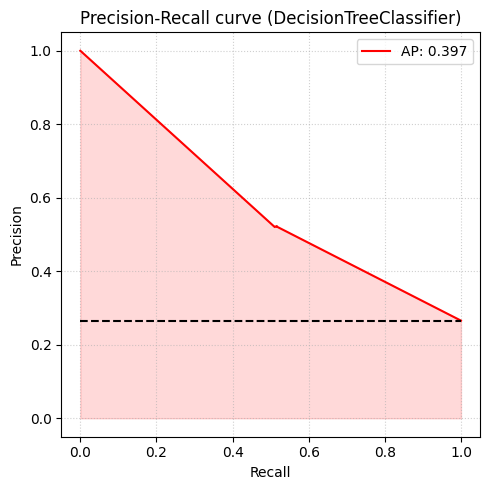

2026-09-08 11:09:12,499 | INFO | evaluate_model | Precision-Recall Curve for DecisionTreeClassifier classification model.


In [23]:
_,_=view_ROC_curve(fitted_pipe_DT,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_DT,X_test,y_test)

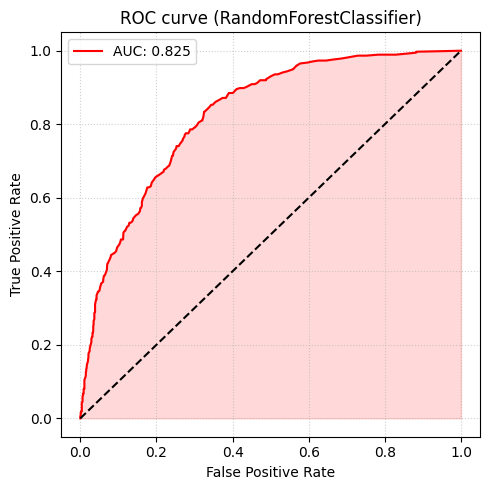

2026-09-08 11:09:12,639 | INFO | evaluate_model | ROC Curve and AUC for RandomForestClassifier classification model.


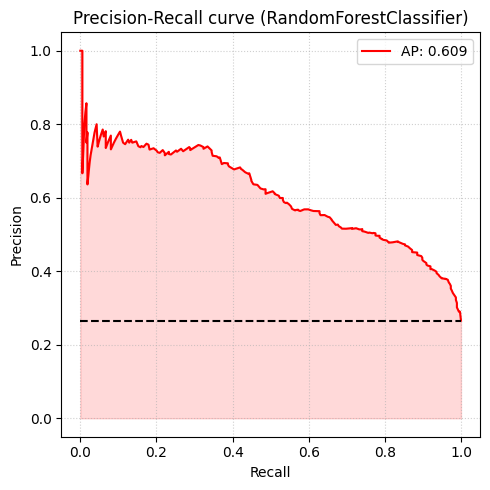

2026-09-08 11:09:12,759 | INFO | evaluate_model | Precision-Recall Curve for RandomForestClassifier classification model.


In [24]:
_,_=view_ROC_curve(fitted_pipe_RF,X_test,y_test)
_,_=view_PR_curve(fitted_pipe_RF,X_test,y_test)

### Quick comparison of LR and XGBoost errors

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
pd.crosstab(fitted_pipe_XGB.predict(X_test),fitted_pipe_LR.predict(X_test))

col_0,0,1
row_0,,
0,819,293
1,21,274


In [27]:
(21+293)/(819+274+21+293)

0.22316986496090974

In [28]:
#22.3% de discordância

In [29]:
y_pred_LR=fitted_pipe_LR.predict(X_test)
y_proba_LR=fitted_pipe_LR.predict_proba(X_test)[:,1]
y_pred_XGB=fitted_pipe_XGB.predict(X_test)
y_proba_XGB=fitted_pipe_XGB.predict_proba(X_test)[:,1]
index=[]
for j in range(len(X_test)):
    if y_pred_LR[j]!=y_pred_XGB[j]:      
        index.append(j)
    else:
        pass

In [30]:
df_proba=pd.DataFrame((y_proba_LR,y_proba_XGB)).T.rename(columns={0:"LR",1:"XGB"})

In [31]:
df_dif=df_proba.iloc[index].copy()
df_dif.head()

,LR,XGB
3,0.751223,0.439500
10,0.534391,0.178867
12,0.511038,0.224710
14,0.510688,0.056038
16,0.619577,0.194481


In [32]:
df_dif["difference"]=df_dif["LR"]-df_dif["XGB"]

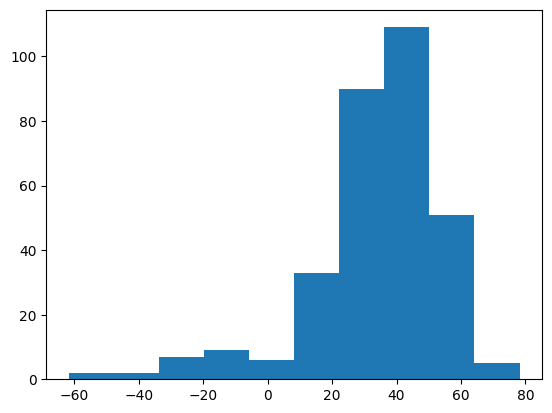

In [33]:
plt.hist(df_dif["difference"].values*100);

In [34]:
df_dif["difference"].mean()

np.float64(0.3406082343297339)

In [35]:
df_dif["difference"].median()

np.float64(0.3706641064813239)

In [36]:
df_dif["difference"].std()

np.float64(0.20641569460787615)